**0. IMPORT LIBRARIES AND DATA FROM CSV FILE**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import  butter, filtfilt, find_peaks
import seaborn as sns

In [39]:
#Load the data
filepath = r'Accelerometer_Sara.csv'
df= pd.read_csv(filepath)
print(df.head())

                  time  seconds_elapsed         z         y         x
0  1777307821192395300         0.113395  0.350617 -0.018412  0.014904
1  1777307821202448100         0.123448  0.199245  0.016247 -0.044721
2  1777307821212500000         0.133500  0.153955 -0.009005 -0.062549
3  1777307821222553300         0.143553  0.019621  0.044261 -0.081745
4  1777307821232606200         0.153606 -0.015769  0.118999 -0.057163


**1. ROW DATA PREPROCESSING** 

First the calculation of the acceleration magnitude, to remove the dependency on the vertical axis.

The filter applied is a Low  Pass filter to cutoff the high frequencies due to vibrations or sensor oscillations.
The applied filter is a Butterworth filter, with cutoff frequency Fc=15 Hz and 4° degree.

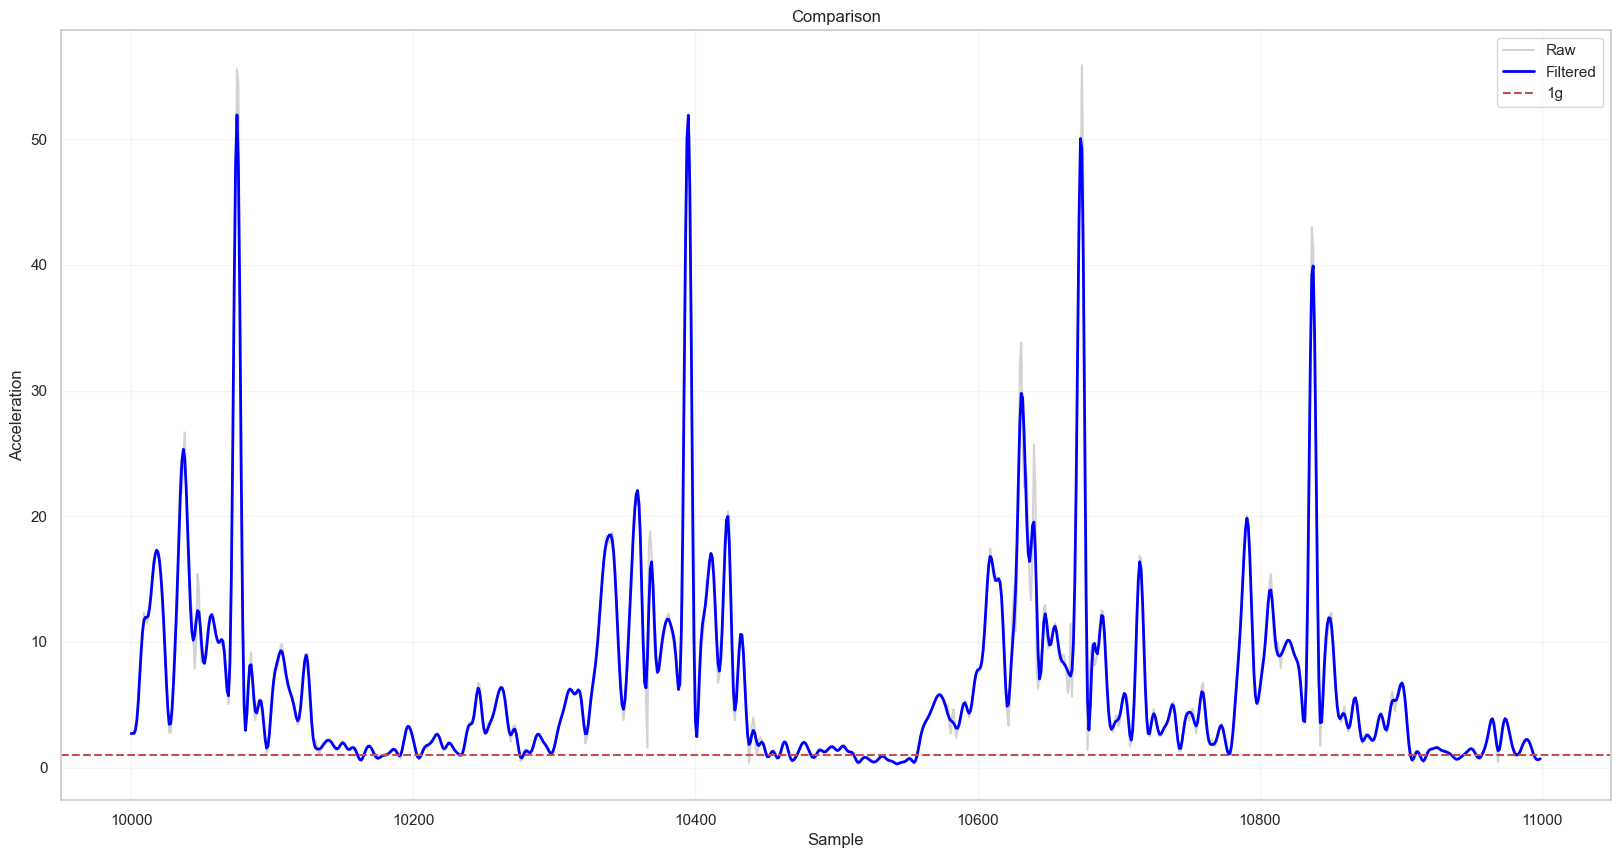

In [40]:
#sampling frequency
Fs= 100.0
#cutoff frequency
Fc= 15.0 

#Acceleration Magnitude
df['Acc_Mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2) 

#Butterworth filter implementation
def butterworth_filter(data, fs, cutoff):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = signal.butter(4, normal_cutoff, btype='low', analog=False)
    return signal.filtfilt(b, a, data)

df['Acc_Filtered'] = butterworth_filter(df['Acc_Mag'], Fs, Fc)

#plot of the raw and filtered signal
plt.figure(figsize=(20, 10))
plt.plot(df['Acc_Mag'][10000:11000], color='lightgray', label='Raw')
plt.plot(df['Acc_Filtered'][10000:11000], color='blue', linewidth=2, label='Filtered')

plt.axhline(y=1.0, color='r', linestyle='--', label='1g')
plt.title('Comparison')
plt.xlabel('Sample')
plt.ylabel('Acceleration')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [41]:
print(f"Mean value, filtered acceleration: {df['Acc_Filtered'].mean()}")
print(f"Min value, filtered acceleration: {df['Acc_Filtered'].min()}")
print(f"Mean value, raw acceleration: {df['Acc_Mag'].mean()}")
print(f"Min value, raw acceleration: {df['Acc_Mag'].min()}")

Mean value, filtered acceleration: 4.040121222744178
Min value, filtered acceleration: -0.48166802136325226
Mean value, raw acceleration: 4.040129639736049
Min value, raw acceleration: 0.018308037979279136


**2. Jump detection and height calculation**
The first method is the time of flight, detecting the take off and landing instant is possible to calculate the time of flight and determine the height with the formula h = 1/8 gt^2.

The jumps taken into account have duration between 200ms and 1s to avoid impossible durations or to include other movement that were not jumps

In [42]:
def jump_detection_TOF(signal, time_array, fs, threshold=0.5, min_duration=0.2, max_duration=1.0):

    in_air = signal < threshold
    #detect state changes (in air or not) to detect the takeoff and landing instants
    diff = np.diff(in_air.astype(int))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    
    if len(ends) > 0 and len(starts) > 0:
        if ends[0] < starts[0]:
            ends = ends[1:]
        if starts[-1] > ends[-1]:
            starts = starts[:-1]
            
    jumps = []
    
    for s, e in zip(starts, ends):
        duration = (e - s) / fs
        
        #duration tresholds set up between 0.2 and 1 second to avoid noise
        if duration >= min_duration and duration <= max_duration:
            height = 0.125 * 9.81 * (duration**2)
            
            jumps.append({
                'start_idx': s,
                'end_idx': e,
                'start_time': time_array[s],
                'end_time': time_array[e],
                'duration': duration,
                'height_cm': height * 100
            })
            
    return jumps

jumps_filt = jump_detection_TOF(df['Acc_Filtered'].values, df.index.values, Fs)
print(f"TOF method: {len(jumps_filt)} jumps:")
for i, j in enumerate(jumps_filt):
    print(f"Jump n. {i+1}: Start time {j['start_time']}, Height {j['height_cm']:.2f} cm")

TOF method: 42 jumps:
Jump n. 1: Start time 1670, Height 11.78 cm
Jump n. 2: Start time 2278, Height 7.66 cm
Jump n. 3: Start time 2340, Height 12.56 cm
Jump n. 4: Start time 2816, Height 8.29 cm
Jump n. 5: Start time 2864, Height 4.91 cm
Jump n. 6: Start time 3555, Height 8.29 cm
Jump n. 7: Start time 3661, Height 5.94 cm
Jump n. 8: Start time 3787, Height 39.84 cm
Jump n. 9: Start time 3847, Height 8.94 cm
Jump n. 10: Start time 3943, Height 16.79 cm
Jump n. 11: Start time 4025, Height 6.49 cm
Jump n. 12: Start time 4117, Height 9.61 cm
Jump n. 13: Start time 4198, Height 7.06 cm
Jump n. 14: Start time 4231, Height 8.29 cm
Jump n. 15: Start time 4263, Height 4.91 cm
Jump n. 16: Start time 4589, Height 10.31 cm
Jump n. 17: Start time 4967, Height 31.89 cm
Jump n. 18: Start time 5026, Height 23.74 cm
Jump n. 19: Start time 5073, Height 25.95 cm
Jump n. 20: Start time 5126, Height 5.41 cm
Jump n. 21: Start time 5154, Height 15.02 cm
Jump n. 22: Start time 7641, Height 29.44 cm
Jump n. 2

**3. Double integration using trapezoidal rule**

This method estimates the jump height by integrating the filtered acceleration twice: first to velocity, then to displacement. The gravity baseline is removed before integration and a linear drift correction is applied to the velocity signal.

Detected peak 41
Detected jumps: 41


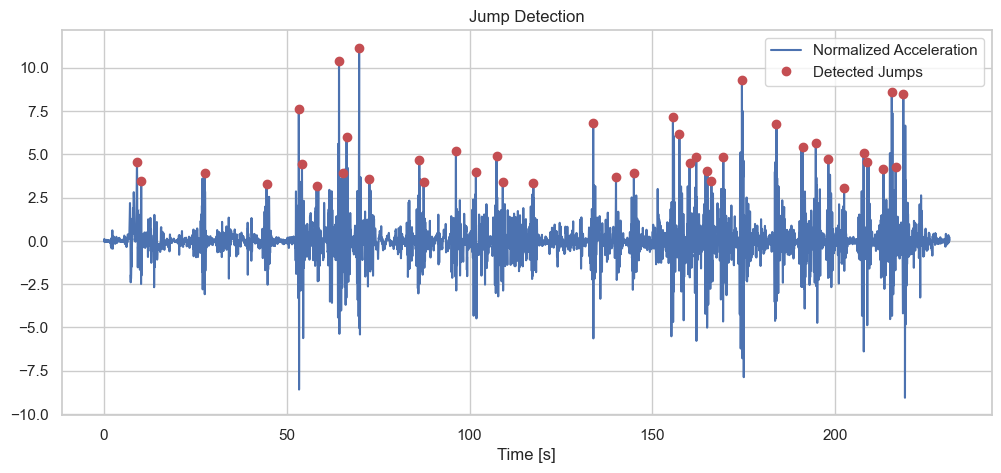


Jump Heights:
Jump 1: 31.8 cm
Jump 2: 4.5 cm
Jump 3: 4.8 cm
Jump 4: 17.0 cm
Jump 5: 33.7 cm
Jump 6: 55.8 cm
Jump 7: 18.0 cm
Jump 8: 17.2 cm
Jump 9: 22.8 cm
Jump 10: 25.8 cm
Jump 11: 37.5 cm
Jump 12: 13.1 cm
Jump 13: 6.3 cm
Jump 14: 9.2 cm
Jump 15: 7.4 cm
Jump 16: 30.0 cm
Jump 17: 6.8 cm
Jump 18: 7.7 cm
Jump 19: 5.2 cm
Jump 20: 14.0 cm
Jump 21: 25.0 cm
Jump 22: 7.1 cm
Jump 23: 11.2 cm
Jump 24: 35.7 cm
Jump 25: 40.2 cm
Jump 26: 15.1 cm
Jump 27: 31.9 cm
Jump 28: 27.7 cm
Jump 29: 11.0 cm
Jump 30: 22.2 cm
Jump 31: 47.6 cm
Jump 32: 23.1 cm
Jump 33: 9.9 cm
Jump 34: 15.5 cm
Jump 35: 7.6 cm
Jump 36: 11.4 cm
Jump 37: 15.0 cm
Jump 38: 21.4 cm
Jump 39: 13.3 cm
Jump 40: 45.7 cm
Jump 41: 25.5 cm

Average height: 0.20280409619602086

method comparison

TOF Time of Flight method:
  Jumps detected: 42
  Average height: 16.13 cm
  Minimum height: 4.91 cm
  Maximum height: 53.42 cm

NDI Numerical Double Integration method:
  Jumps detected: 41
  Average height: 20.28 cm
  Minimum height: 4.50 cm
  Maxim

In [43]:
t = df["seconds_elapsed"].values
y = df["y"].values
#vertical acceleration is on y axis
a = y 
a = a - np.mean(a)
#filtering
b, a_filt_coeff = butter(4, Fc/(Fs/2), btype='low')
a_filt = filtfilt(b, a_filt_coeff, a)
#normalization
a_norm = (a_filt - np.mean(a_filt)) / np.std(a_filt)

# Peak detection
peaks, _ = find_peaks(
    a_norm,
    height=3,
    distance=int(Fs * 0.8),
    prominence=2
)

print("Detected peak", len(peaks))
#jumps detection with a minimum time distance to avoid multiple detections for the same jump
filtered_peaks = []
for p in peaks:
    if len(filtered_peaks) == 0:
        filtered_peaks.append(p)
    else:
        if (t[p] - t[filtered_peaks[-1]]) > 0.8:
            filtered_peaks.append(p)
print("Detected jumps:", len(filtered_peaks))


plt.figure(figsize=(12,5))
plt.plot(t, a_norm, label="Normalized Acceleration")
plt.plot(t[filtered_peaks], a_norm[filtered_peaks], "ro", label="Detected Jumps")
plt.legend()
plt.title("Jump Detection")
plt.xlabel("Time [s]")
plt.show()

# #DNI METHOD
# heights = []

# for p in filtered_peaks:

#     #JUMP window
#     window = int(Fs * 1.5)  # 1.5 secondi
#     start = max(0, p - window//2)
#     end = min(len(a_filt), p + window//2)

#     a_seg = a_filt[start:end]
#     t_seg = t[start:end]

#     a_seg = a_seg - np.mean(a_seg)

#     #first integration, acceleration to velocity
#     v = np.zeros_like(a_seg)
#     for i in range(1, len(a_seg)):
#         dt = t_seg[i] - t_seg[i-1]
#         v[i] = v[i-1] + 0.5 * (a_seg[i] + a_seg[i-1]) * dt

#     v = v - np.mean(v[:10])

#     #second integration, velocity to vertical displacement
#     s = np.zeros_like(v)
#     for i in range(1, len(v)):
#         dt = t_seg[i] - t_seg[i-1]
#         s[i] = s[i-1] + 0.5 * (v[i] + v[i-1]) * dt

#     #height calculated as maximum displacement
#     height = np.max(s) - np.min(s)
#     heights.append(height)
heights = []
jumps_double = [] 

for i, p in enumerate(filtered_peaks):

    # finestra intorno al salto
    window = int(Fs * 1.5)  # 1.5 secondi
    start = max(0, p - window//2)
    end = min(len(a_filt), p + window//2)

    a_seg = a_filt[start:end]
    t_seg = t[start:end]

    # rimuovi bias locale
    a_seg = a_seg - np.mean(a_seg)

    # integrazione → velocità
    v = np.zeros_like(a_seg)
    for j in range(1, len(a_seg)):
        dt = t_seg[j] - t_seg[j-1]
        v[j] = v[j-1] + 0.5 * (a_seg[j] + a_seg[j-1]) * dt

    # ZUPT (velocità iniziale = 0)
    v = v - np.mean(v[:10])

    # integrazione → posizione
    s = np.zeros_like(v)
    for j in range(1, len(v)):
        dt = t_seg[j] - t_seg[j-1]
        s[j] = s[j-1] + 0.5 * (v[j] + v[j-1]) * dt

    # Calcolo parametri richiesti
    height_m = np.max(s) - np.min(s)
    height_cm = height_m * 100
    duration = t_seg[-1] - t_seg[0]

    # Creazione dizionario per il salto corrente
    jump_data = {
        "start_idx": start,
        "end_idx": end,
        "start_time": t_seg[0],
        "end_time": t_seg[-1],
        "duration": duration,
        "height_cm": height_cm
    }
    
    jumps_double.append(jump_data)
    heights.append(height_m)

#results
df_jumps = pd.DataFrame(jumps_double)

print("\nJump Heights:")
for i, h in enumerate(heights):
    print(f"Jump {i+1}: {(h*100):.1f} cm")

print("\nAverage height:", np.mean(heights))

#TOF vs DNI comparison
print("\n" + "="*60)
print("method comparison")

df_filt = pd.DataFrame(jumps_filt)
if len(df_filt) > 0:
    print(f"\nTOF Time of Flight method:")
    print(f"  Jumps detected: {len(df_filt)}")
    print(f"  Average height: {df_filt['height_cm'].mean():.2f} cm")
    print(f"  Minimum height: {df_filt['height_cm'].min():.2f} cm")
    print(f"  Maximum height: {df_filt['height_cm'].max():.2f} cm")

if len(df_jumps) > 0:
    print(f"\nNDI Numerical Double Integration method:")
    print(f"  Jumps detected: {len(df_jumps)}")
    print(f"  Average height: {df_jumps['height_cm'].mean():.2f} cm")
    print(f"  Minimum height: {df_jumps['height_cm'].min():.2f} cm")
    print(f"  Maximum height: {df_jumps['height_cm'].max():.2f} cm")



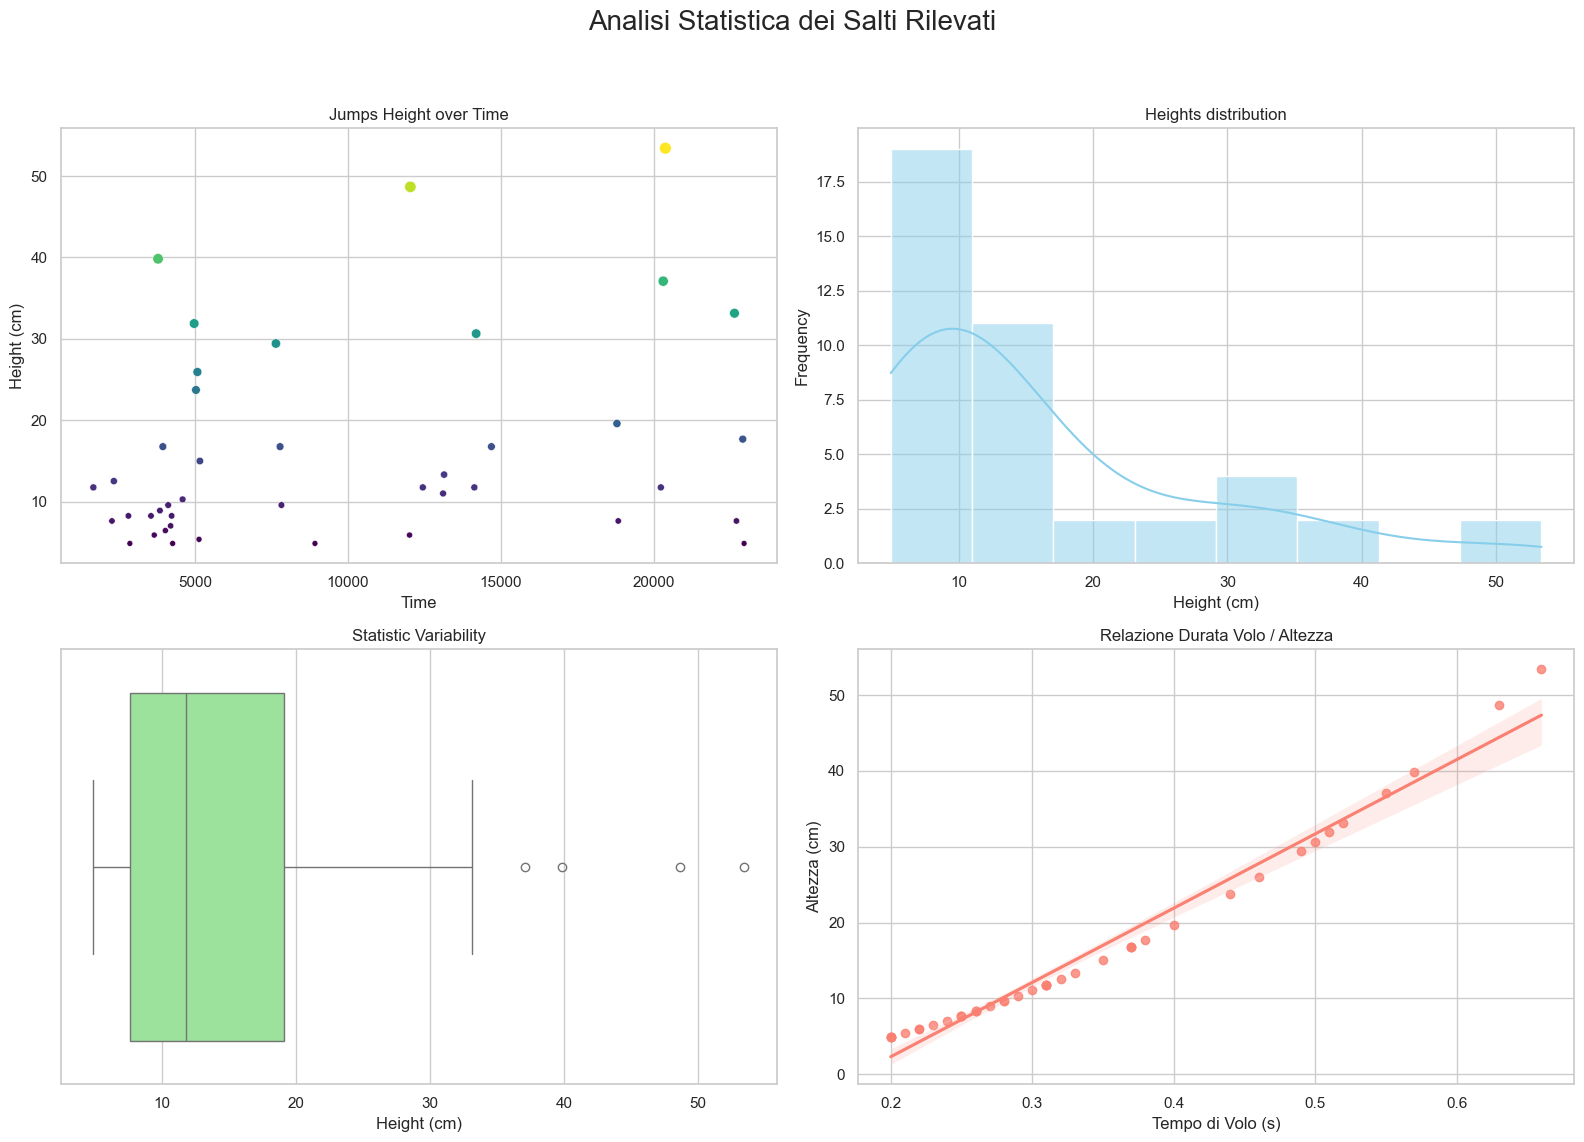

Resume
count    42.000000
mean     16.129567
std      12.339551
min       4.905000
25%       7.664062
50%      11.784263
75%      19.141763
max      53.415450
Name: height_cm, dtype: object


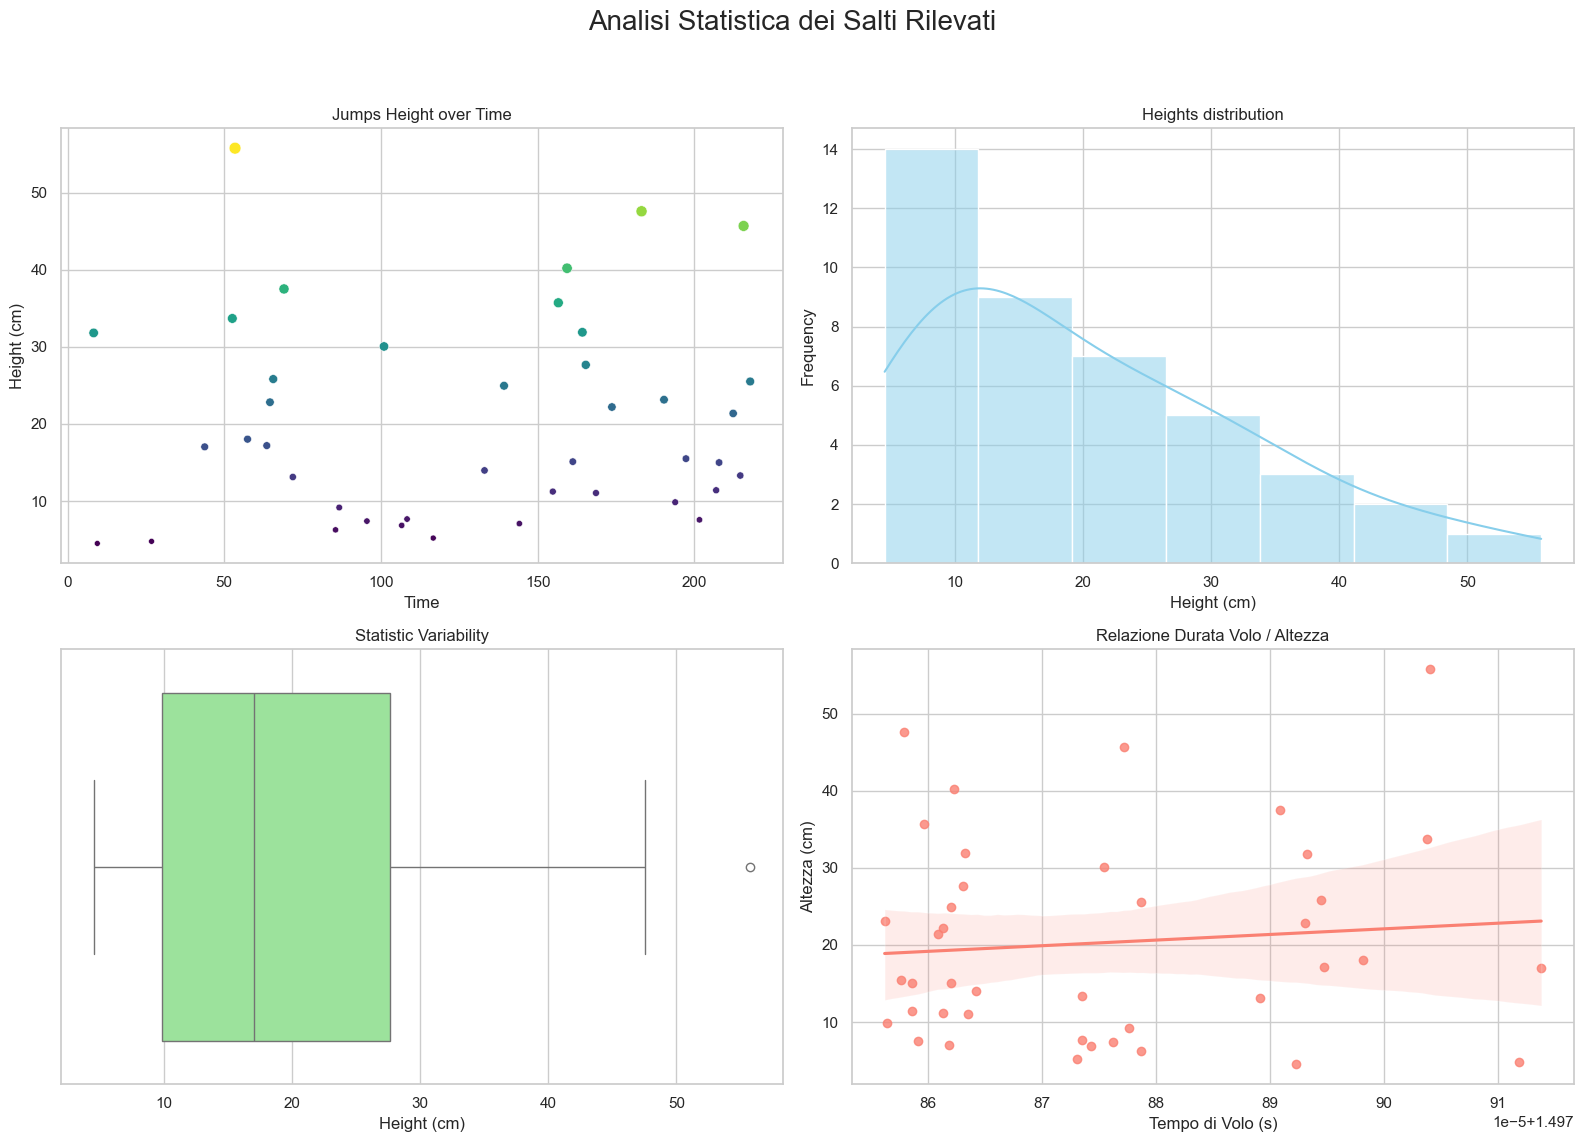

Resume
count    41.000000
mean     20.280410
std      12.990298
min       4.504096
25%       9.851402
50%      17.030333
75%      27.658607
max      55.754357
Name: height_cm, dtype: object


In [44]:
def plot_jump_analysis(jumps):

    if not jumps:
        print("No jumps.")
        return
    df_jumps = pd.DataFrame(jumps)
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Analisi Statistica dei Salti Rilevati', fontsize=20)

    #Height over time
    sns.scatterplot(ax=axes[0, 0], data=df_jumps, x='start_time', y='height_cm', 
                    size='height_cm', hue='height_cm', palette='viridis', legend=False)
    axes[0, 0].set_title('Jumps Height over Time')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('Height (cm)')

    #Height distribution
    sns.histplot(ax=axes[0, 1], data=df_jumps, x='height_cm', kde=True, color='skyblue')
    axes[0, 1].set_title('Heights distribution')
    axes[0, 1].set_xlabel('Height (cm)')
    axes[0, 1].set_ylabel('Frequency')

    #Boxplot to visualizee outliers
    sns.boxplot(ax=axes[1, 0], x=df_jumps['height_cm'], color='lightgreen')
    axes[1, 0].set_title('Statistic Variability')
    axes[1, 0].set_xlabel('Height (cm)')

    #relation between duration and height (Physical validation)
    sns.regplot(ax=axes[1, 1], data=df_jumps, x='duration', y='height_cm', color='salmon')
    axes[1, 1].set_title('Relazione Durata Volo / Altezza')
    axes[1, 1].set_xlabel('Tempo di Volo (s)')
    axes[1, 1].set_ylabel('Altezza (cm)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


    print("Resume")
    print(df_jumps['height_cm'].describe().apply(lambda x: format(x, 'f')))

plot_jump_analysis(jumps_filt)
plot_jump_analysis(jumps_double)